# Análisis Exploratorio de Datos (EDA) - Procesos RPA

Este notebook realiza un análisis exploratorio de una base SQLite llamada **`Procesos_clean.db`**, ubicada en la ruta relativa:

```text
Data/database/Procesos_clean.db
```

El objetivo es entender el comportamiento operativo de los procesos RPA, validar calidad de datos, convertir variables críticas a formatos analizables, detectar valores atípicos y generar conclusiones útiles para el informe del proyecto.

**Competencias cubiertas:**

- Carga de datos desde SQLite.
- Inspección automática de tablas disponibles.
- Limpieza y normalización básica de columnas.
- Conversión de duraciones a segundos y minutos.
- Análisis estadístico descriptivo.
- Tablas de frecuencia para variables categóricas.
- Visualización de distribuciones y relaciones.
- Detección de outliers con método IQR.
- Interpretación final en estilo informe.

## 1. Configuración e importación de librerías

> Ejecuta esta celda primero. Si alguna librería no está instalada, instala el paquete correspondiente desde una celda nueva con `!pip install nombre_paquete`.

In [1]:
import os
import sqlite3
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Configuración visual
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

%matplotlib inline

## 2. Definición de ruta y validación del archivo SQLite

Esta sección corrige el error principal del notebook original: la variable `db_path` no estaba definida antes de intentar cargar la base de datos.

In [2]:
# Ruta esperada del archivo dentro del proyecto
DB_PATH = Path("Data/database/Procesos_clean.db")

# Ruta alternativa útil si ejecutas el notebook desde otra carpeta
rutas_alternativas = [
    DB_PATH,
    Path.cwd() / DB_PATH,
    Path.cwd().parent / DB_PATH,
]

ruta_encontrada = None
for ruta in rutas_alternativas:
    if ruta.exists():
        ruta_encontrada = ruta.resolve()
        break

if ruta_encontrada is None:
    print("No se encontró la base de datos en las rutas evaluadas:")
    for ruta in rutas_alternativas:
        print(" -", ruta.resolve())
    raise FileNotFoundError(
        "No se encontró Procesos_clean.db. Verifica que exista en Data/database/Procesos_clean.db "
        "y que estés ejecutando el notebook desde la raíz del proyecto."
    )

print(f"Base de datos encontrada en: {ruta_encontrada}")

Base de datos encontrada en: C:\Users\guzme\OneDrive\Documentos\Proyecto1Especializacion\data\database\Procesos_clean.db


## 3. Inspección de tablas disponibles en la base de datos

Antes de cargar los datos, se consultan las tablas disponibles. Esto evita depender de un nombre fijo de tabla y hace el notebook más robusto.

In [3]:
with sqlite3.connect(ruta_encontrada) as conn:
    tablas = pd.read_sql_query(
        """
        SELECT name AS tabla
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name;
        """,
        conn
    )

print("Tablas disponibles en la base de datos:")
display(tablas)

if tablas.empty:
    raise ValueError("La base de datos no contiene tablas.")

Tablas disponibles en la base de datos:


,tabla
0,RegistrosDPA_clean
1,RolesAreas_clean
2,TiemposManuales_clean


## 4. Carga de datos

El notebook intenta usar primero una tabla llamada `RegistrosDPA`, porque era la que aparecía en tu versión inicial. Si esa tabla no existe, toma la primera tabla disponible.

In [4]:
TABLA_PREFERIDA = "RegistrosDPA"

if TABLA_PREFERIDA in tablas["tabla"].tolist():
    tabla_objetivo = TABLA_PREFERIDA
else:
    tabla_objetivo = tablas["tabla"].iloc[0]

print(f"Tabla seleccionada para el análisis: {tabla_objetivo}")

with sqlite3.connect(ruta_encontrada) as conn:
    df = pd.read_sql_query(f'SELECT * FROM "{tabla_objetivo}";', conn)

print(f"Registros cargados: {df.shape[0]:,}")
print(f"Columnas cargadas: {df.shape[1]:,}")
display(df.head())

Tabla seleccionada para el análisis: RegistrosDPA_clean
Registros cargados: 618,875
Columnas cargadas: 11


,Automatizacion,Duracion_Ejecucion,Numero_Transacciones,Celula,Fecha_ejecucion,Hora_Ejecucion,Exitosas,ErroresNegocio,Area,TipoEjecucion,IdProceso
0,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,09:58:37 PM,0.00,0.00,Afiliacion,T,505100
1,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:01:20 PM,0.00,0.00,Afiliacion,T,505105
2,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:02:48 PM,0.00,0.00,Afiliacion,T,505107
3,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:03:29 PM,0.00,0.00,Afiliacion,T,505108
4,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:06:30 PM,0.00,0.00,Afiliacion,T,505113


## 5. Exploración inicial de estructura y calidad de datos

En esta sección se revisan tipos de datos, valores nulos, duplicados y columnas disponibles.

In [5]:
print("Columnas disponibles:")
for col in df.columns:
    print(" -", col)

print("\nInformación general del DataFrame:")
display(df.info())

resumen_calidad = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": [df[col].dtype for col in df.columns],
    "nulos": [df[col].isna().sum() for col in df.columns],
    "porcentaje_nulos": [df[col].isna().mean() * 100 for col in df.columns],
    "valores_unicos": [df[col].nunique(dropna=True) for col in df.columns]
}).sort_values("porcentaje_nulos", ascending=False)

print(f"\nFilas duplicadas exactas: {df.duplicated().sum():,}")
display(resumen_calidad)

Columnas disponibles:
 - Automatizacion
 - Duracion_Ejecucion
 - Numero_Transacciones
 - Celula
 - Fecha_ejecucion
 - Hora_Ejecucion
 - Exitosas
 - ErroresNegocio
 - Area
 - TipoEjecucion
 - IdProceso

Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 618875 entries, 0 to 618874
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Automatizacion        618875 non-null  str    
 1   Duracion_Ejecucion    57172 non-null   str    
 2   Numero_Transacciones  618875 non-null  int64  
 3   Celula                618875 non-null  str    
 4   Fecha_ejecucion       618761 non-null  str    
 5   Hora_Ejecucion        617923 non-null  str    
 6   Exitosas              617703 non-null  float64
 7   ErroresNegocio        617658 non-null  float64
 8   Area                  614385 non-null  str    
 9   TipoEjecucion         614301 non-null  str    
 10  IdProceso             618875 non-n

None


Filas duplicadas exactas: 0


,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos
1,Duracion_Ejecucion,str,561703,90.76,9120
9,TipoEjecucion,str,4574,0.74,2
8,Area,str,4490,0.73,24
7,ErroresNegocio,float64,1217,0.20,634
6,Exitosas,float64,1172,0.19,1058
5,Hora_Ejecucion,str,952,0.15,121438
4,Fecha_ejecucion,str,114,0.02,1611
2,Numero_Transacciones,int64,0,0.00,1702
0,Automatizacion,str,0,0.00,84
3,Celula,str,0,0.00,8


## 6. Funciones auxiliares para preparar variables

Estas funciones ayudan a encontrar columnas aunque tengan pequeñas variaciones en el nombre, por ejemplo `Fecha_ejecucion`, `Fecha Ejecución`, `fecha`, etc.

In [6]:
def normalizar_nombre_columna(nombre):
    """Normaliza nombres de columnas para facilitar búsquedas flexibles."""
    return (
        str(nombre)
        .strip()
        .lower()
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace("ñ", "n")
        .replace(" ", "_")
        .replace("-", "_")
    )


def buscar_columna(df, candidatos):
    """Busca una columna por lista de posibles nombres normalizados."""
    mapa = {normalizar_nombre_columna(col): col for col in df.columns}
    for candidato in candidatos:
        candidato_norm = normalizar_nombre_columna(candidato)
        if candidato_norm in mapa:
            return mapa[candidato_norm]
    return None


def duracion_a_segundos(valor):
    """
    Convierte duraciones a segundos.
    Soporta formatos como:
    - HH:MM:SS
    - MM:SS
    - segundos numéricos
    - valores tipo timedelta
    """
    if pd.isna(valor):
        return np.nan

    if isinstance(valor, pd.Timedelta):
        return valor.total_seconds()

    if isinstance(valor, (int, float, np.integer, np.floating)):
        return float(valor)

    texto = str(valor).strip()
    if texto == "":
        return np.nan

    # Intento 1: pandas timedelta, útil para HH:MM:SS
    try:
        return pd.to_timedelta(texto).total_seconds()
    except Exception:
        pass

    # Intento 2: separación manual por dos puntos
    try:
        partes = [float(p) for p in texto.split(":")]
        if len(partes) == 3:
            h, m, s = partes
            return h * 3600 + m * 60 + s
        if len(partes) == 2:
            m, s = partes
            return m * 60 + s
    except Exception:
        pass

    return np.nan


def detectar_outliers_iqr(data, columna):
    """Detecta outliers usando el rango intercuartílico IQR."""
    serie = pd.to_numeric(data[columna], errors="coerce").dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)].copy()
    return outliers, limite_inferior, limite_superior

## 7. Preparación de variables para el análisis

Aquí se identifican automáticamente columnas clave como automatización, duración, transacciones y fecha. Si tu base tiene nombres diferentes, puedes ajustar las listas de candidatos.

In [7]:
# Identificación flexible de columnas relevantes
col_automatizacion = buscar_columna(df, [
    "Automatizacion", "Automatización", "Proceso", "Nombre_Proceso", "Robot", "Bot", "RPA"
])

col_duracion = buscar_columna(df, [
    "Duracion_Ejecucion", "Duración_Ejecución", "Duracion", "Duración", "Tiempo_Ejecucion", "Tiempo", "Runtime"
])

col_transacciones = buscar_columna(df, [
    "Numero_Transacciones", "Número_Transacciones", "Transacciones", "Cantidad_Transacciones", "Registros", "Items", "Casos"
])

col_fecha = buscar_columna(df, [
    "Fecha_ejecucion", "Fecha_Ejecucion", "Fecha", "Fecha_Inicio", "Fecha_Final", "Created", "Timestamp"
])

print("Columnas identificadas:")
print("Automatización:", col_automatizacion)
print("Duración:", col_duracion)
print("Transacciones:", col_transacciones)
print("Fecha:", col_fecha)

# Copia de trabajo
df_eda = df.copy()

# Crear duración en segundos y minutos
if col_duracion is not None:
    df_eda["Duracion_Segundos"] = df_eda[col_duracion].apply(duracion_a_segundos)
    df_eda["Duracion_Minutos"] = df_eda["Duracion_Segundos"] / 60
else:
    print("Advertencia: no se encontró una columna de duración. Se omiten métricas de duración.")

# Crear transacciones numéricas
if col_transacciones is not None:
    df_eda["Numero_Transacciones_Num"] = pd.to_numeric(df_eda[col_transacciones], errors="coerce")
else:
    print("Advertencia: no se encontró una columna de transacciones. Se omiten métricas de volumen.")

# Crear variables de fecha
if col_fecha is not None:
    df_eda["Fecha_Ejecucion_dt"] = pd.to_datetime(df_eda[col_fecha], errors="coerce")
    df_eda["Anio"] = df_eda["Fecha_Ejecucion_dt"].dt.year
    df_eda["Mes"] = df_eda["Fecha_Ejecucion_dt"].dt.month
    df_eda["Dia_Semana"] = df_eda["Fecha_Ejecucion_dt"].dt.day_name(locale=None)
    df_eda["Hora"] = df_eda["Fecha_Ejecucion_dt"].dt.hour
else:
    print("Advertencia: no se encontró una columna de fecha. Se omite análisis temporal.")

# Indicador de automatización/proceso para gráficos
if col_automatizacion is None:
    df_eda["Automatizacion_Analisis"] = "Proceso no identificado"
    col_automatizacion = "Automatizacion_Analisis"

print("\nVista de datos preparados:")
display(df_eda.head())

Columnas identificadas:
Automatización: Automatizacion
Duración: Duracion_Ejecucion
Transacciones: Numero_Transacciones
Fecha: Fecha_ejecucion

Vista de datos preparados:


,Automatizacion,Duracion_Ejecucion,Numero_Transacciones,Celula,Fecha_ejecucion,Hora_Ejecucion,Exitosas,ErroresNegocio,Area,TipoEjecucion,IdProceso,Duracion_Segundos,Duracion_Minutos,Numero_Transacciones_Num,Fecha_Ejecucion_dt,Anio,Mes,Dia_Semana,Hora
0,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,09:58:37 PM,0.00,0.00,Afiliacion,T,505100,NaN,NaN,1,2024-06-07,"2,024.00",6.00,Friday,0.00
1,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:01:20 PM,0.00,0.00,Afiliacion,T,505105,NaN,NaN,1,2024-06-07,"2,024.00",6.00,Friday,0.00
2,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:02:48 PM,0.00,0.00,Afiliacion,T,505107,NaN,NaN,1,2024-06-07,"2,024.00",6.00,Friday,0.00
3,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:03:29 PM,0.00,0.00,Afiliacion,T,505108,NaN,NaN,1,2024-06-07,"2,024.00",6.00,Friday,0.00
4,RPA_Validacion_Automatica_Documentos,NaN,1,Servicios Organizacionales,2024-06-07,10:06:30 PM,0.00,0.00,Afiliacion,T,505113,NaN,NaN,1,2024-06-07,"2,024.00",6.00,Friday,0.00


## 8. Estadística descriptiva

Resumen de las variables numéricas disponibles después de la preparación.

In [8]:
columnas_numericas = df_eda.select_dtypes(include=["number"]).columns.tolist()

if columnas_numericas:
    resumen_numerico = df_eda[columnas_numericas].describe().T
    resumen_numerico["mediana"] = df_eda[columnas_numericas].median(numeric_only=True)
    resumen_numerico["varianza"] = df_eda[columnas_numericas].var(numeric_only=True)
    resumen_numerico["nulos"] = df_eda[columnas_numericas].isna().sum()
    display(resumen_numerico)
else:
    print("No se identificaron columnas numéricas para describir.")

,count,mean,std,min,25%,50%,75%,max,mediana,varianza,nulos
Numero_Transacciones,"618,875.00",15.28,390.85,1.00,1.00,1.00,1.00,"103,772.00",1.00,"152,765.77",0
Exitosas,"617,703.00",7.05,634.64,0.00,0.00,0.00,0.00,"467,373.00",0.00,"402,763.39",1172
ErroresNegocio,"617,658.00",431.71,"15,449.02",-46.00,0.00,0.00,0.00,"555,555.00",0.00,"238,672,166.02",1217
IdProceso,"618,875.00","543,713.79","332,855.10",1.00,"253,744.50","531,198.00","822,233.50","1,217,809.00","531,198.00","110,792,519,587.17",0
Duracion_Segundos,"57,172.00","2,321.25","6,192.49",0.00,80.00,603.00,"1,659.00","125,424.00",603.00,"38,346,895.12",561703
Duracion_Minutos,"57,172.00",38.69,103.21,0.00,1.33,10.05,27.65,"2,090.40",10.05,"10,651.92",561703
Numero_Transacciones_Num,"618,875.00",15.28,390.85,1.00,1.00,1.00,1.00,"103,772.00",1.00,"152,765.77",0
Anio,"618,761.00","2,024.20",0.90,"2,021.00","2,024.00","2,024.00","2,025.00","2,026.00","2,024.00",0.81,114
Mes,"618,761.00",5.89,3.55,1.00,2.00,6.00,9.00,12.00,6.00,12.58,114
Hora,"618,761.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,114


## 9. Frecuencias de variables categóricas

Se muestran las 10 categorías más frecuentes para las variables de texto con cardinalidad razonable.

In [9]:
columnas_categoricas = df_eda.select_dtypes(include=["object", "category"]).columns.tolist()

for col in columnas_categoricas:
    unicos = df_eda[col].nunique(dropna=True)
    if 1 < unicos <= 30:
        print(f"\nFrecuencia para: {col}")
        display(
            df_eda[col]
            .value_counts(dropna=False)
            .head(10)
            .rename_axis(col)
            .reset_index(name="frecuencia")
        )


Frecuencia para: Celula


,Celula,frecuencia
0,Servicios Organizacionales,583685
1,CelulaTransversal,16756
2,CelulaSalud,12324
3,ServiciosOrganizacionales,2576
4,Soporte_Personas&Familias,2534
5,Soporte Contenidos,883
6,Viaje y Recreacion,103
7,Educacion,14



Frecuencia para: Area


,Area,frecuencia
0,Afiliacion,560967
1,Empresas,9121
2,Empleo,7038
3,Afiliaciones,6229
4,Aportes,5872
5,Tesoreria,5026
6,NaN,4490
7,Vacunacion,3569
8,Punto virtual,2876
9,Facturacion,2132



Frecuencia para: TipoEjecucion


,TipoEjecucion,frecuencia
0,T,595273
1,E,19028
2,NaN,4574



Frecuencia para: Dia_Semana


,Dia_Semana,frecuencia
0,Wednesday,112771
1,Thursday,107291
2,Tuesday,104148
3,Friday,102145
4,Saturday,77255
5,Monday,74501
6,Sunday,40650
7,NaN,114


## 10. Análisis de outliers

Se detectan valores atípicos en duración y transacciones con el método IQR. Estos casos no necesariamente son errores; pueden representar ejecuciones con alto volumen, fallos, reprocesos o condiciones especiales de operación.

In [10]:
variables_outliers = []

if "Duracion_Segundos" in df_eda.columns:
    variables_outliers.append("Duracion_Segundos")

if "Numero_Transacciones_Num" in df_eda.columns:
    variables_outliers.append("Numero_Transacciones_Num")

resumen_outliers = []
outliers_por_variable = {}

for variable in variables_outliers:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df_eda, variable)
    outliers_por_variable[variable] = outliers
    resumen_outliers.append({
        "variable": variable,
        "limite_inferior": lim_inf,
        "limite_superior": lim_sup,
        "cantidad_outliers": len(outliers),
        "porcentaje_outliers": len(outliers) / len(df_eda) * 100 if len(df_eda) > 0 else 0
    })

resumen_outliers_df = pd.DataFrame(resumen_outliers)
display(resumen_outliers_df)

for variable, outliers in outliers_por_variable.items():
    print(f"\nMuestra de outliers para {variable}:")
    columnas_mostrar = [col for col in [col_automatizacion, col_fecha, col_duracion, col_transacciones, variable] if col is not None and col in outliers.columns]
    display(outliers[columnas_mostrar].head(10))

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
0,Duracion_Segundos,"-2,288.50","4,027.50",6761,1.09
1,Numero_Transacciones_Num,1.00,1.00,30663,4.95



Muestra de outliers para Duracion_Segundos:


,Automatizacion,Fecha_ejecucion,Duracion_Ejecucion,Numero_Transacciones,Duracion_Segundos
474,GestorRemitidos,2024-06-15,16:25:10,1144,"59,110.00"
496,Vacunacion tradicional carga de información,2023-12-10,03:12:46,970,"11,566.00"
497,Vacunacion tradicional carga de información,2023-12-10,03:13:50,320,"11,630.00"
501,Convocatorias Atom,2023-12-11,01:53:11,1,"6,791.00"
531,AtomHojaVida,2023-12-11,01:41:43,528,"6,103.00"
532,GestorRemitidos,2023-12-11,03:46:44,369,"13,604.00"
533,Vacunacion tradicional carga de información,2023-12-11,02:48:35,7719,"10,115.00"
534,Vacunacion tradicional carga de información,2023-12-11,02:49:14,397,"10,154.00"
535,Vacunacion tradicional carga de información,2023-12-11,02:03:51,6723,"7,431.00"
536,Vacunacion tradicional carga de información,2023-12-11,02:04:25,397,"7,465.00"



Muestra de outliers para Numero_Transacciones_Num:


,Automatizacion,Fecha_ejecucion,Duracion_Ejecucion,Numero_Transacciones,Numero_Transacciones_Num
393,Aseguramiento venta empresarial - Transcriptor,2024-06-15,00:00:36,30,30
448,Aseguramiento venta empresarial,2024-06-15,00:08:37,5,5
462,Aseguramiento venta empresarial,2024-06-15,00:08:55,5,5
474,GestorRemitidos,2024-06-15,16:25:10,1144,1144
496,Vacunacion tradicional carga de información,2023-12-10,03:12:46,970,970
497,Vacunacion tradicional carga de información,2023-12-10,03:13:50,320,320
504,AtomHojaVida,2023-12-11,00:40:15,120,120
506,Aseguramiento venta empresarial,2023-12-11,00:08:36,4,4
507,Aseguramiento venta empresarial - Transcriptor,2023-12-11,00:00:31,7,7
510,Novedades Nomina Instructores,2023-12-11,00:17:36,59,59


## 11. Visualizaciones principales

Las siguientes gráficas ayudan a interpretar distribución, dispersión, correlación y comportamiento por proceso.

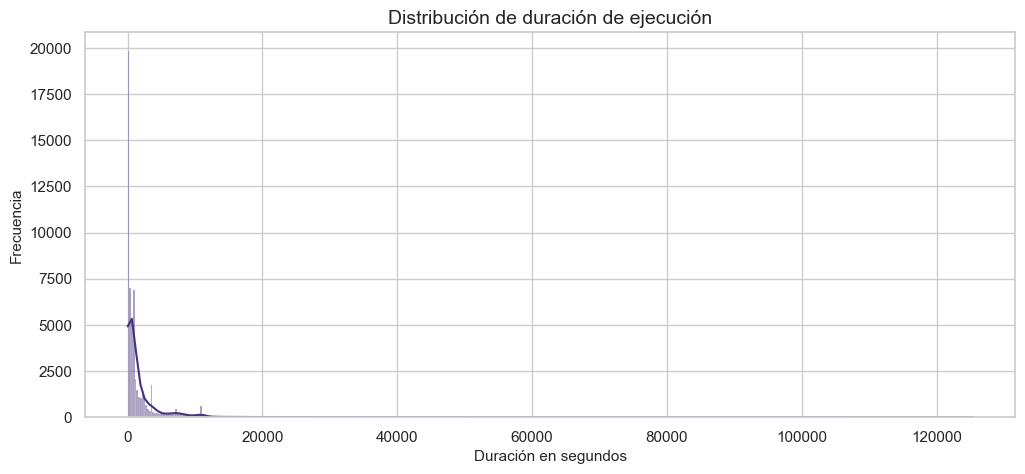

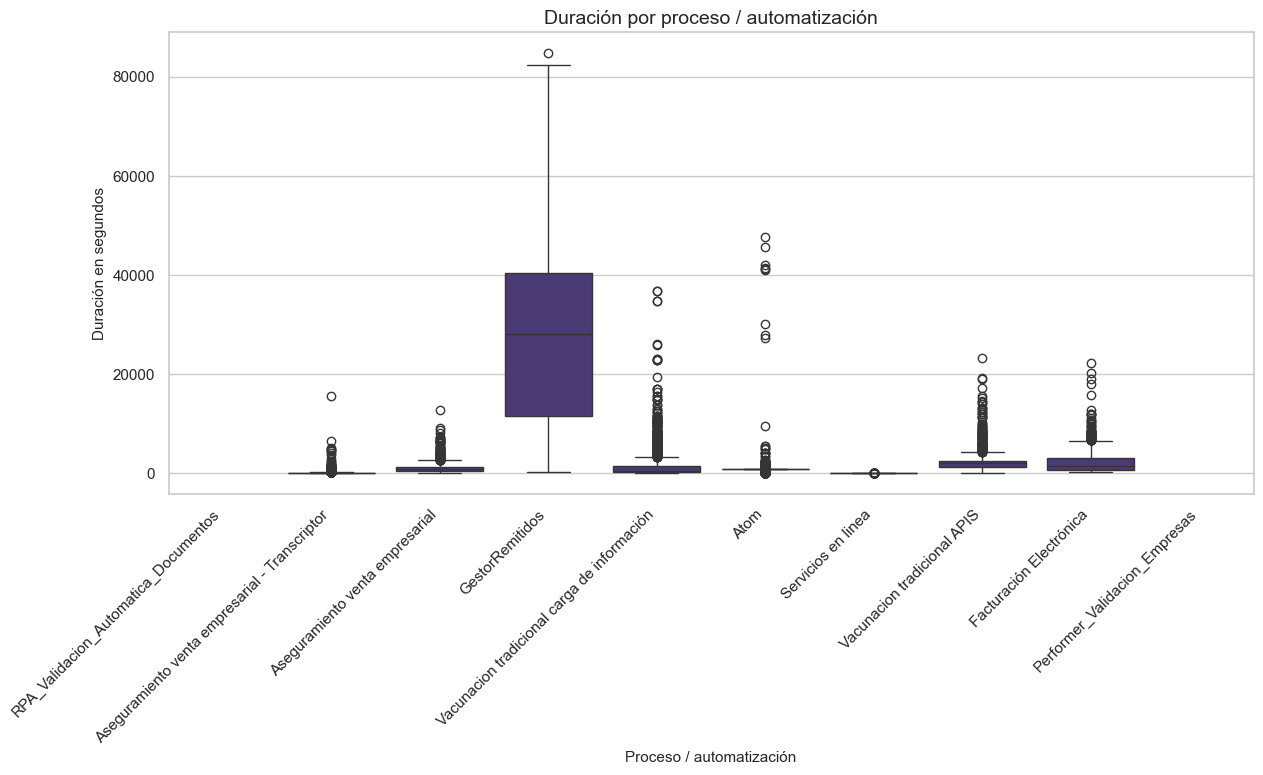

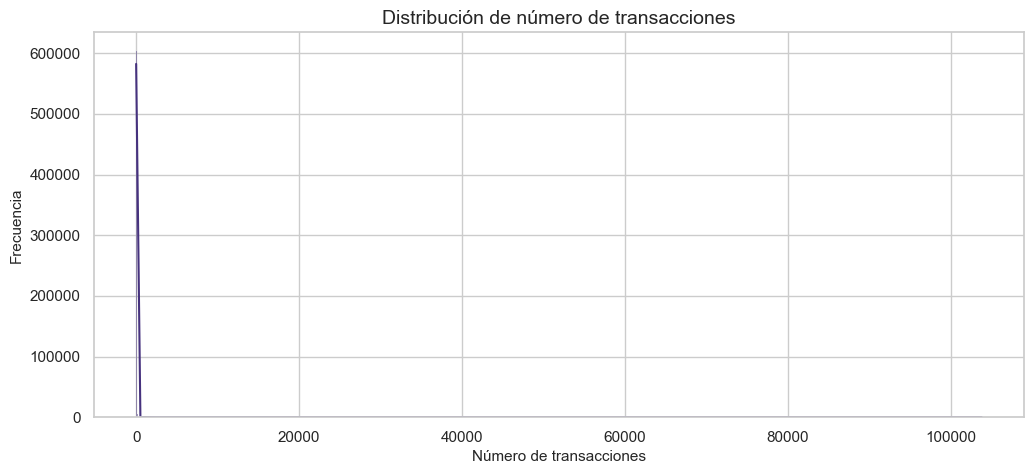

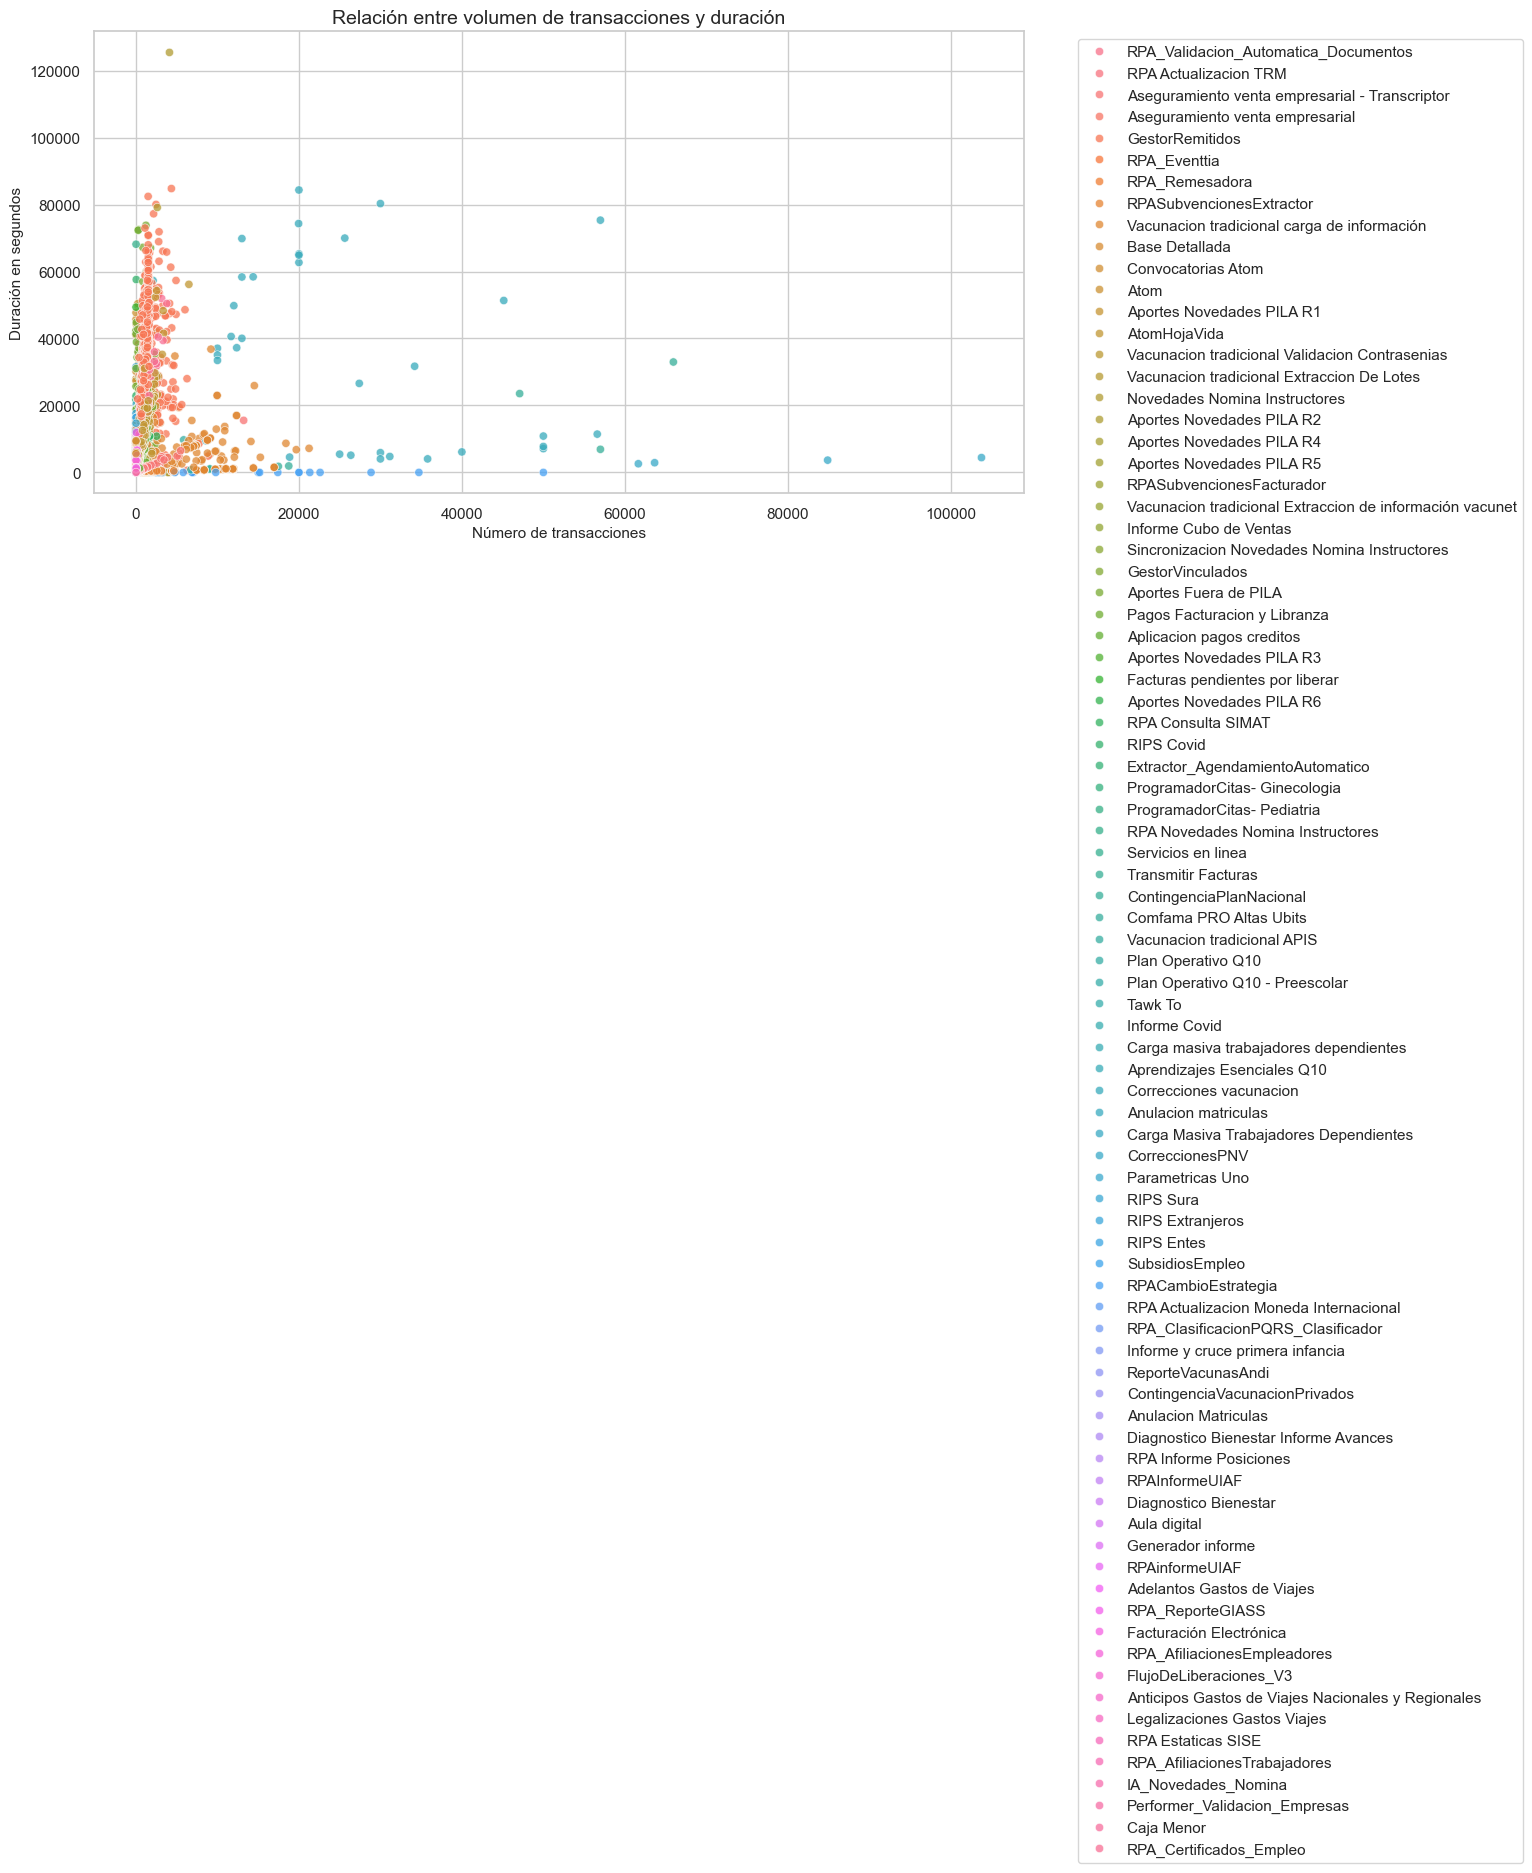

In [11]:
# 1. Distribución de duración
if "Duracion_Segundos" in df_eda.columns:
    plt.figure(figsize=(12, 5))
    sns.histplot(df_eda["Duracion_Segundos"].dropna(), kde=True)
    plt.title("Distribución de duración de ejecución")
    plt.xlabel("Duración en segundos")
    plt.ylabel("Frecuencia")
    plt.show()

# 2. Boxplot de duración por automatización/proceso
if "Duracion_Segundos" in df_eda.columns and col_automatizacion in df_eda.columns:
    top_procesos = df_eda[col_automatizacion].value_counts().head(10).index
    df_top = df_eda[df_eda[col_automatizacion].isin(top_procesos)]
    
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_top, x=col_automatizacion, y="Duracion_Segundos")
    plt.title("Duración por proceso / automatización")
    plt.xlabel("Proceso / automatización")
    plt.ylabel("Duración en segundos")
    plt.xticks(rotation=45, ha="right")
    plt.show()

# 3. Distribución de transacciones
if "Numero_Transacciones_Num" in df_eda.columns:
    plt.figure(figsize=(12, 5))
    sns.histplot(df_eda["Numero_Transacciones_Num"].dropna(), kde=True)
    plt.title("Distribución de número de transacciones")
    plt.xlabel("Número de transacciones")
    plt.ylabel("Frecuencia")
    plt.show()

# 4. Relación duración vs transacciones
if {"Duracion_Segundos", "Numero_Transacciones_Num"}.issubset(df_eda.columns):
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=df_eda,
        x="Numero_Transacciones_Num",
        y="Duracion_Segundos",
        hue=col_automatizacion if col_automatizacion in df_eda.columns else None,
        alpha=0.75
    )
    plt.title("Relación entre volumen de transacciones y duración")
    plt.xlabel("Número de transacciones")
    plt.ylabel("Duración en segundos")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

## 12. Correlación entre variables numéricas

La matriz de correlación permite observar qué variables tienen relación lineal. Una correlación alta entre transacciones y duración puede indicar que el tiempo de ejecución depende del volumen procesado.

,Duracion_Segundos,Duracion_Minutos,Numero_Transacciones_Num,Anio,Mes,Hora
Duracion_Segundos,1.00,1.00,0.21,-0.01,0.02,NaN
Duracion_Minutos,1.00,1.00,0.21,-0.01,0.02,NaN
Numero_Transacciones_Num,0.21,0.21,1.00,-0.04,0.01,NaN
Anio,-0.01,-0.01,-0.04,1.00,-0.40,NaN
Mes,0.02,0.02,0.01,-0.40,1.00,NaN
Hora,NaN,NaN,NaN,NaN,NaN,NaN


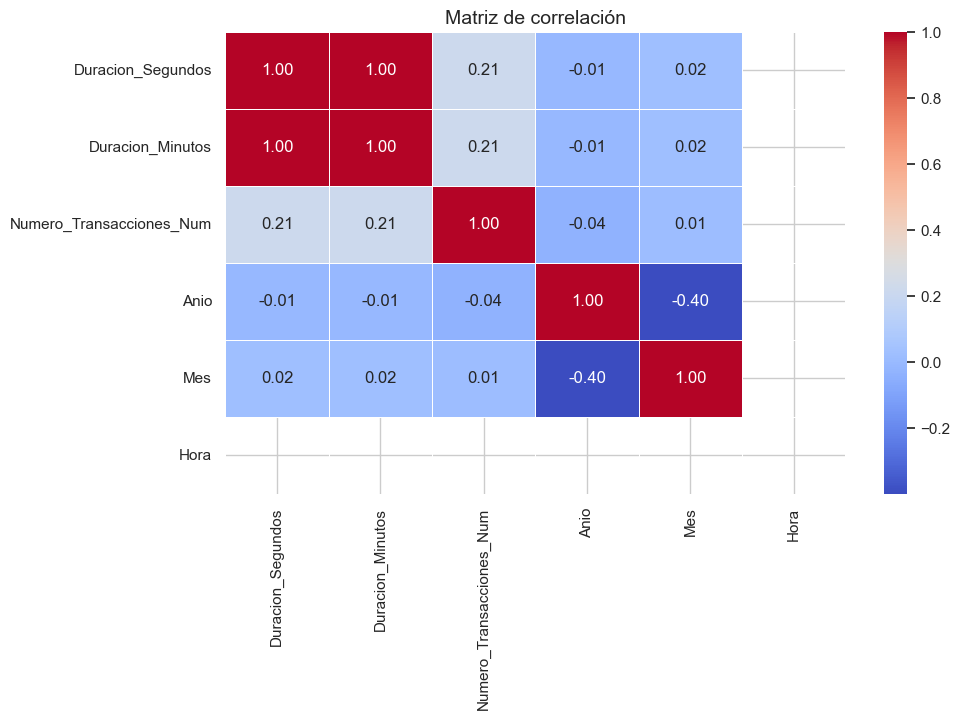

In [12]:
columnas_corr = [
    col for col in ["Duracion_Segundos", "Duracion_Minutos", "Numero_Transacciones_Num", "Anio", "Mes", "Hora"]
    if col in df_eda.columns
]

if len(columnas_corr) >= 2:
    matriz_corr = df_eda[columnas_corr].corr()
    display(matriz_corr)

    plt.figure(figsize=(10, 6))
    sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matriz de correlación")
    plt.show()
else:
    print("No hay suficientes columnas numéricas para calcular correlación.")

## 13. Análisis temporal

Esta sección resume ejecuciones por mes, día de la semana u hora, si existe una columna de fecha válida.

,Periodo_Mensual,ejecuciones,duracion_promedio_seg,transacciones_promedio
0,2021-01,1,0.00,1.00
1,2021-05,1,"28,170.00",313.00
2,2021-06,1,"5,454.00","1,337.00"
3,2021-07,1,"4,770.00","1,567.00"
4,2021-08,2,"4,284.50","1,002.00"
5,2021-09,3,"4,013.00",519.00
6,2021-10,6,"26,614.17","1,228.83"
7,2021-11,15,"9,458.60","4,893.20"
8,2021-12,95,"2,334.17",606.79
9,2022-01,143,"1,301.57",119.55


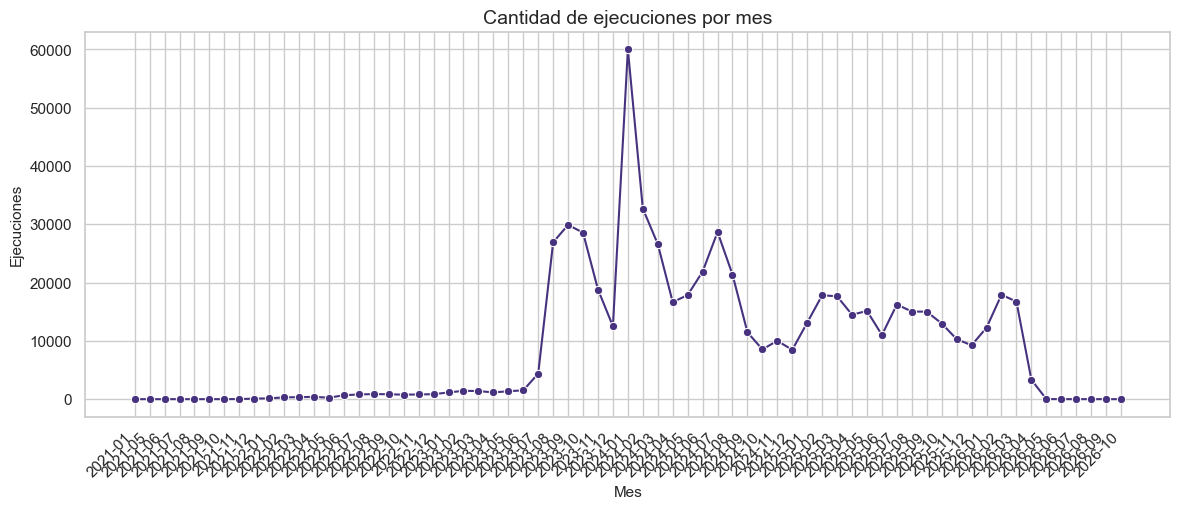

In [13]:
if "Fecha_Ejecucion_dt" in df_eda.columns and df_eda["Fecha_Ejecucion_dt"].notna().any():
    df_temporal = df_eda.dropna(subset=["Fecha_Ejecucion_dt"]).copy()
    df_temporal["Periodo_Mensual"] = df_temporal["Fecha_Ejecucion_dt"].dt.to_period("M").astype(str)

    resumen_mensual = df_temporal.groupby("Periodo_Mensual").agg(
        ejecuciones=("Fecha_Ejecucion_dt", "count"),
        duracion_promedio_seg=("Duracion_Segundos", "mean") if "Duracion_Segundos" in df_temporal.columns else ("Fecha_Ejecucion_dt", "count"),
        transacciones_promedio=("Numero_Transacciones_Num", "mean") if "Numero_Transacciones_Num" in df_temporal.columns else ("Fecha_Ejecucion_dt", "count")
    ).reset_index()

    display(resumen_mensual.head(12))

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=resumen_mensual, x="Periodo_Mensual", y="ejecuciones", marker="o")
    plt.title("Cantidad de ejecuciones por mes")
    plt.xlabel("Mes")
    plt.ylabel("Ejecuciones")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No se encontró una columna de fecha válida para análisis temporal.")

## 14. Ranking de procesos por duración y volumen

Este resumen permite identificar procesos candidatos a optimización, especialmente aquellos con alta duración promedio o alto volumen operativo.

In [14]:
agg_dict = {"cantidad_ejecuciones": (col_automatizacion, "count")}

if "Duracion_Segundos" in df_eda.columns:
    agg_dict.update({
        "duracion_promedio_seg": ("Duracion_Segundos", "mean"),
        "duracion_mediana_seg": ("Duracion_Segundos", "median"),
        "duracion_maxima_seg": ("Duracion_Segundos", "max"),
    })

if "Numero_Transacciones_Num" in df_eda.columns:
    agg_dict.update({
        "transacciones_promedio": ("Numero_Transacciones_Num", "mean"),
        "transacciones_totales": ("Numero_Transacciones_Num", "sum"),
    })

ranking_procesos = (
    df_eda
    .groupby(col_automatizacion, dropna=False)
    .agg(**agg_dict)
    .reset_index()
)

orden = "duracion_promedio_seg" if "duracion_promedio_seg" in ranking_procesos.columns else "cantidad_ejecuciones"
ranking_procesos = ranking_procesos.sort_values(orden, ascending=False)

display(ranking_procesos.head(15))

,Automatizacion,cantidad_ejecuciones,duracion_promedio_seg,duracion_mediana_seg,duracion_maxima_seg,transacciones_promedio,transacciones_totales
26,Correcciones vacunacion,40,"30,841.38","29,149.00","84,341.00","22,276.85",891074
35,GestorRemitidos,1707,"26,840.98","28,019.00","84,772.00",984.97,1681346
66,RPA_Certificados_Empleo,48,"14,817.79","9,624.50","51,925.00","1,005.98",48287
5,Aportes Fuera de PILA,598,"9,957.79","6,981.00","73,796.00",219.36,131179
48,ProgramadorCitas- Ginecologia,845,"7,338.01","8,257.00","18,035.00",63.50,53661
25,Convocatorias Atom,1021,"7,190.33","7,235.00","12,982.00",1.00,1021
51,RIPS Entes,66,"7,092.05","6,697.50","18,870.00",1.11,73
43,Pagos Facturacion y Libranza,940,"6,321.99","5,116.50","72,310.00",145.50,136771
16,AtomHojaVida,1590,"5,552.20","3,663.50","56,166.00",427.86,680302
12,Aprendizajes Esenciales Q10,19,"5,528.42","3,147.00","57,309.00",223.89,4254


## 15. Conclusiones en estilo informe

> Ajusta los textos según los resultados reales obtenidos al ejecutar el notebook.

In [16]:
conclusiones = []

conclusiones.append(f"Se cargaron {len(df_eda):,} registros desde la tabla '{tabla_objetivo}' de la base SQLite Procesos_clean.db.")

if "Duracion_Segundos" in df_eda.columns:
    duracion_prom = df_eda["Duracion_Segundos"].mean()
    duracion_med = df_eda["Duracion_Segundos"].median()
    conclusiones.append(
        f"La duración promedio de las ejecuciones fue de {duracion_prom:,.2f} segundos, "
        f"mientras que la mediana fue de {duracion_med:,.2f} segundos. "
        "Cuando la media es mayor que la mediana, puede existir influencia de ejecuciones atípicamente largas."
    )

if "Numero_Transacciones_Num" in df_eda.columns:
    trans_prom = df_eda["Numero_Transacciones_Num"].mean()
    conclusiones.append(
        f"El volumen promedio procesado fue de {trans_prom:,.2f} transacciones por ejecución. "
        "Esta variable es importante para explicar diferencias en tiempos de procesamiento entre ejecuciones."
    )

if not resumen_outliers_df.empty:
    for _, row in resumen_outliers_df.iterrows():
        conclusiones.append(
            f"Para la variable {row['variable']} se identificaron {int(row['cantidad_outliers'])} valores atípicos "
            f"equivalentes al {row['porcentaje_outliers']:.2f}% de los registros. "
            "Estos casos deben revisarse individualmente antes de eliminarlos, porque pueden representar ejecuciones reales de alta complejidad."
        )

if {"Duracion_Segundos", "Numero_Transacciones_Num"}.issubset(df_eda.columns):
    corr = df_eda[["Duracion_Segundos", "Numero_Transacciones_Num"]].corr().iloc[0, 1]
    conclusiones.append(
        f"La correlación entre duración y número de transacciones fue de {corr:.2f}. "
        "Valores cercanos a 1 indican una relación positiva fuerte; valores cercanos a 0 indican baja relación lineal."
    )

print("CONCLUSIONES PRINCIPALES\n")
for i, conclusion in enumerate(conclusiones, start=1):
    print(f"{i}. {conclusion}\n")

CONCLUSIONES PRINCIPALES

1. Se cargaron 618,875 registros desde la tabla 'RegistrosDPA_clean' de la base SQLite Procesos_clean.db.

2. La duración promedio de las ejecuciones fue de 2,321.25 segundos, mientras que la mediana fue de 603.00 segundos. Cuando la media es mayor que la mediana, puede existir influencia de ejecuciones atípicamente largas.

3. El volumen promedio procesado fue de 15.28 transacciones por ejecución. Esta variable es importante para explicar diferencias en tiempos de procesamiento entre ejecuciones.

4. Para la variable Duracion_Segundos se identificaron 6761 valores atípicos equivalentes al 1.09% de los registros. Estos casos deben revisarse individualmente antes de eliminarlos, porque pueden representar ejecuciones reales de alta complejidad.

5. Para la variable Numero_Transacciones_Num se identificaron 30663 valores atípicos equivalentes al 4.95% de los registros. Estos casos deben revisarse individualmente antes de eliminarlos, porque pueden representar eje